In [10]:
#DV: rating row[8]
#IDVs: abv - row[6], raters - row[9], text - row[12]-row[30]
import numpy as np
import matplotlib.pyplot as plt
import csv
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

#import data from CSVs
data = []
files=["../2_Database/TopBeerData.csv","../2_Database/GoodBeerData.csv","../2_Database/RestBeerData.csv"]
for i in range (0,len(files)):
    with open(files[i],"r",encoding="utf-8") as file:
        reader = csv.reader(file)
        for row in reader:
            row.append(i)
            data.append(row)

all_numeric_data = []
#for j in range (0,len(data)):
numeric_data = []
for row in data[1:]:  # ignore heading
    numeric_data.append([
        float(row[6]),  # abv
        float(row[9]),   # raters
        float(row[12]),
        float(row[13]),
        float(row[14]),
        float(row[15]),
        float(row[16]),
        float(row[17]),
        float(row[18]),
        float(row[19]),
        float(row[20]),
        float(row[21]),
        float(row[22]),
        float(row[23]),
        float(row[24]),
        float(row[25]),
        float(row[26]),
        float(row[27]),
        float(row[28]),
        float(row[29]),
        float(row[30]),
        float(row[31]) #id 0-Top, 1-Good, 2-Rest need to stay the last coloumn
    ])
numeric_data = np.array(numeric_data)
all_numeric_data.append(numeric_data)

combined = np.vstack(all_numeric_data)
print(combined.shape)

#IDVs + DV def
#only to use top beers (0) OR good beers (1)
mask = (numeric_data[:, -1] == 0) | (numeric_data[:, -1] == 1)
filtered_data = numeric_data[mask]
X = filtered_data[:, :-1]
y = filtered_data[:, -1] == 0 #true if 0, else otherwise

# train-test split randomly
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# model
model = LogisticRegression(max_iter=1000)
# train
model.fit(X_train, y_train)

# prediction
y_pred = model.predict(X_test)
# accuracy
acc = accuracy_score(y_test, y_pred)

print(acc)

(2300, 22)
0.8333333333333334


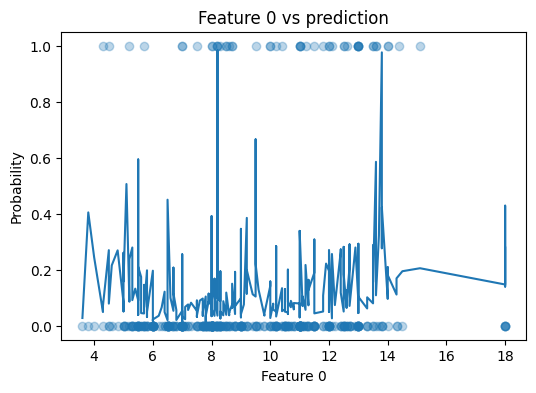

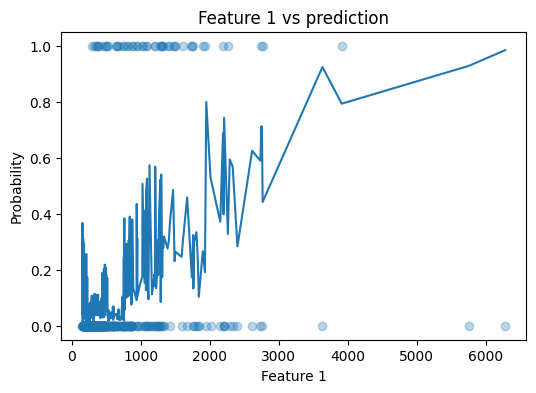

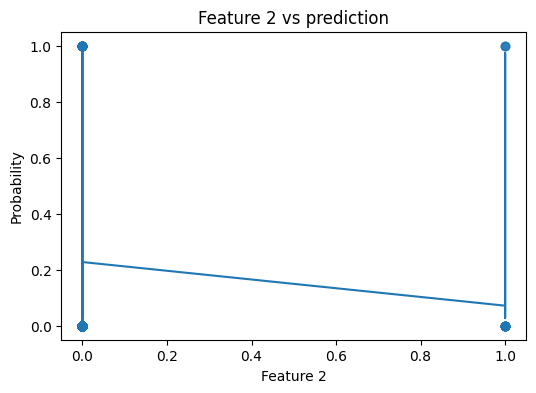

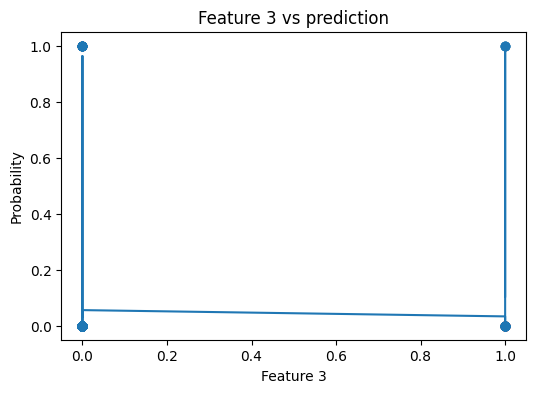

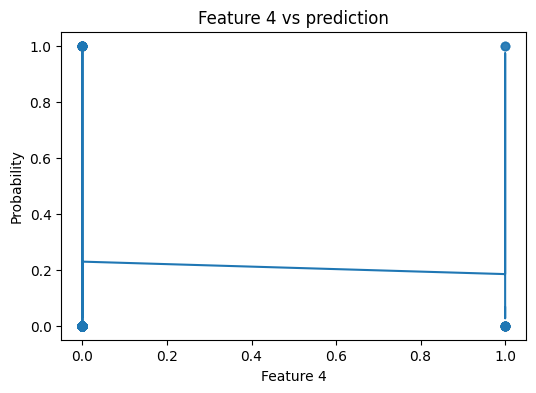

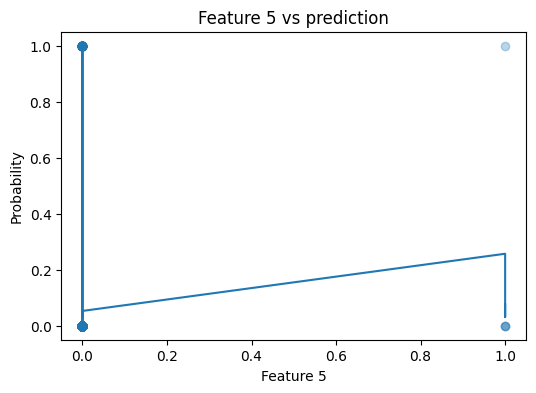

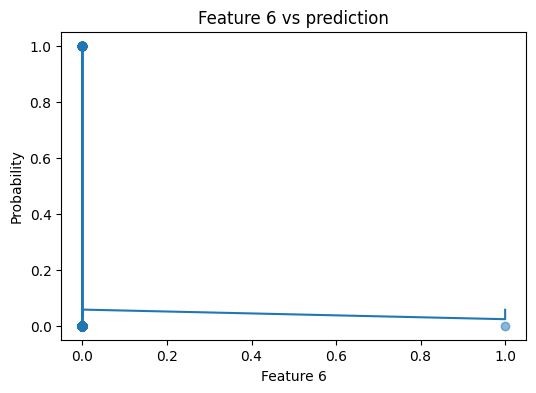

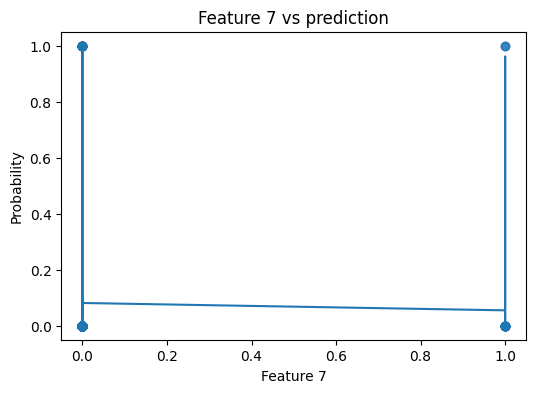

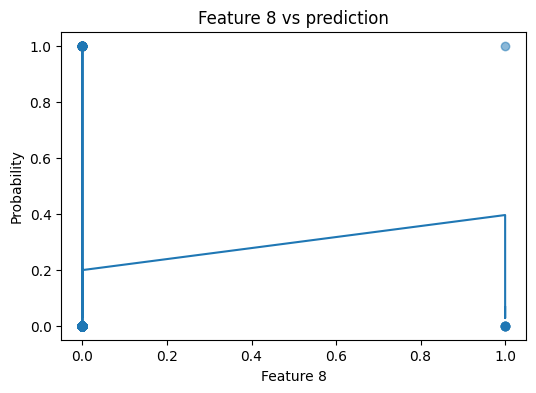

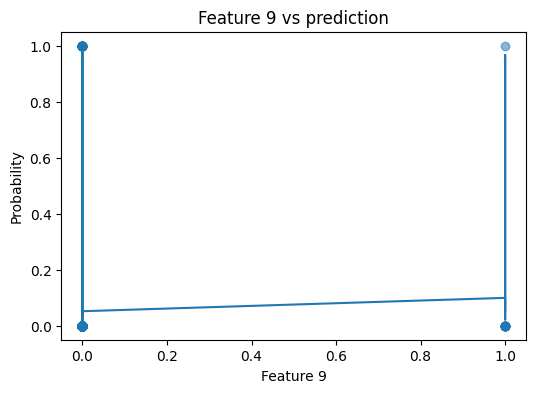

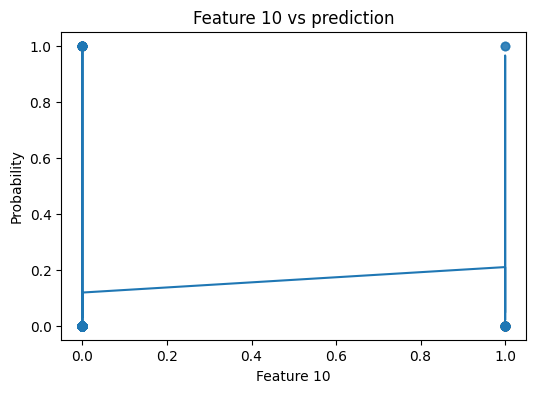

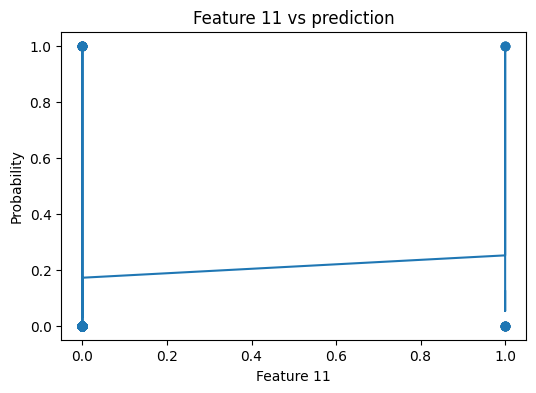

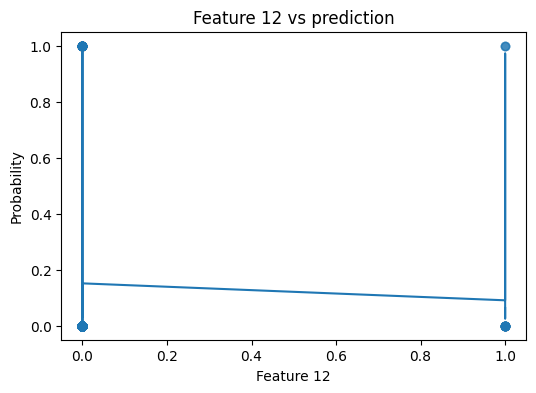

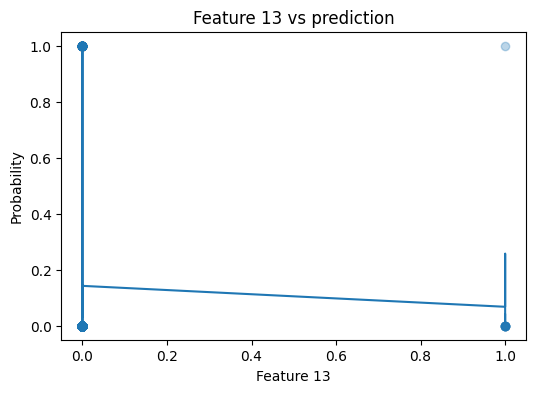

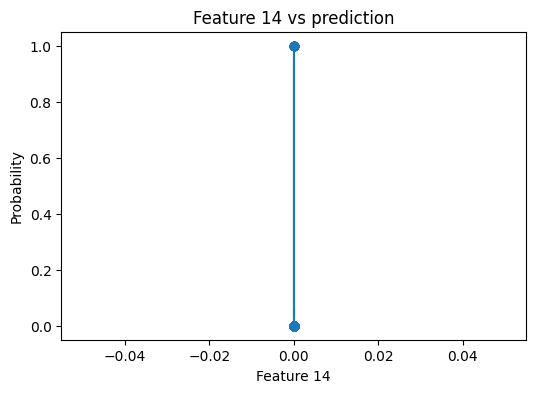

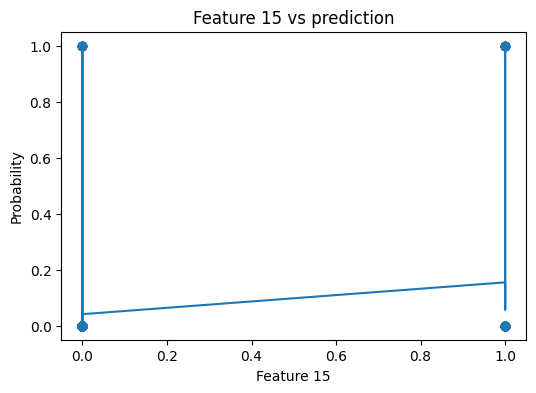

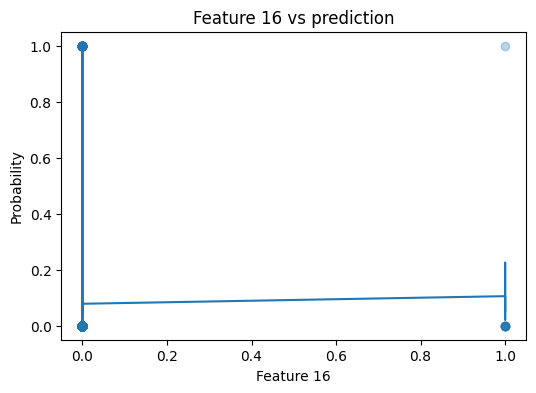

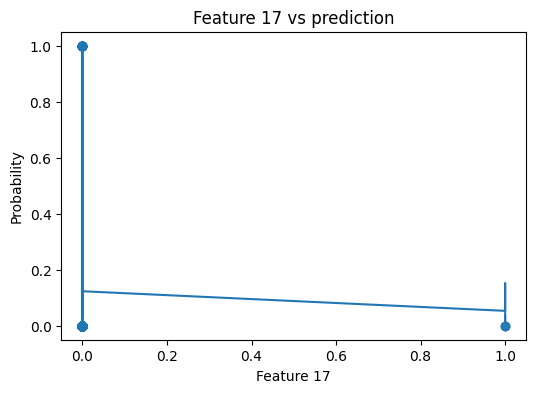

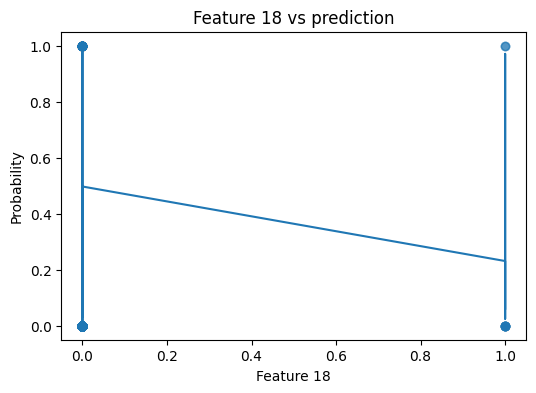

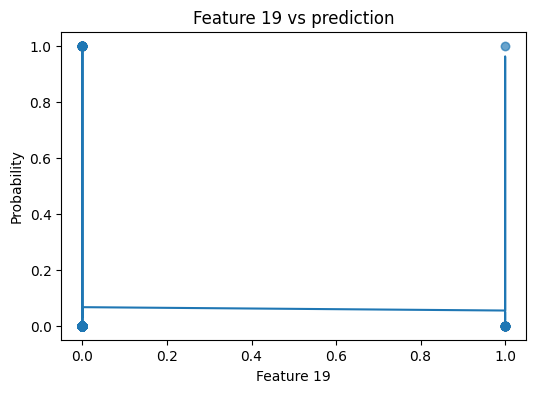

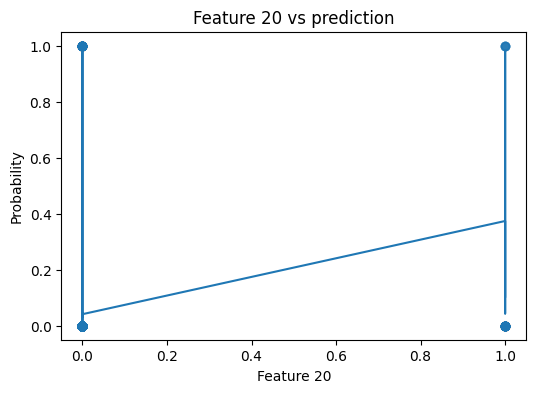

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression

# modell
model = LogisticRegression(max_iter=1000)
model.fit(X, y)

n_features = X.shape[1]

for i in range(n_features):

    x_feature = X[:, i]

    # scatter
    plt.figure(figsize=(6,4))
    plt.scatter(x_feature, y, alpha=0.3)

    # rendezés a szép görbéhez
    idx = np.argsort(x_feature)

    x_sorted = x_feature[idx]

    # teljes X másolása
    X_temp = X.copy()

    # csak az i-edik feature változik
    X_temp[:, i] = x_sorted

    # valószínűségek
    y_prob = model.predict_proba(X_temp)[:, 1]

    # görbe
    plt.plot(x_sorted, y_prob)

    plt.xlabel(f"Feature {i}")
    plt.ylabel("Probability")
    plt.title(f"Feature {i} vs prediction")

    plt.show()